In [ ]:
ANN

In [41]:
import pandas as pd
import numpy as np
import warnings 
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [43]:
df = pd.read_csv("C:\\Users\\ASUS\\OneDrive\\Desktop\\ExcelR assignments\\18\\Neural networks\\Alphabets_data.csv")
df

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,D,2,2,3,3,2,7,7,7,6,6,6,4,2,8,3,7
19996,C,7,10,8,8,4,4,8,6,9,12,9,13,2,9,3,7
19997,T,6,9,6,7,5,6,11,3,7,11,9,5,2,12,2,4
19998,S,2,3,4,2,1,8,7,2,6,10,6,8,1,9,5,8


In [45]:
print("Number of Unique elements in the Dataset: ")
for i in df.columns:
    print(f'{i} has {df[i].nunique()} Unique elements in the {i} column')

Number of Unique elements in the Dataset: 
letter has 26 Unique elements in the letter column
xbox has 16 Unique elements in the xbox column
ybox has 16 Unique elements in the ybox column
width has 16 Unique elements in the width column
height has 16 Unique elements in the height column
onpix has 16 Unique elements in the onpix column
xbar has 16 Unique elements in the xbar column
ybar has 16 Unique elements in the ybar column
x2bar has 16 Unique elements in the x2bar column
y2bar has 16 Unique elements in the y2bar column
xybar has 16 Unique elements in the xybar column
x2ybar has 16 Unique elements in the x2ybar column
xy2bar has 16 Unique elements in the xy2bar column
xedge has 16 Unique elements in the xedge column
xedgey has 16 Unique elements in the xedgey column
yedge has 16 Unique elements in the yedge column
yedgex has 16 Unique elements in the yedgex column


In [ ]:
It looks like the dataset has 17 columns and 20000 rows with letter column having 26 unique items in the column and all other
columns have 16 unique items.

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   letter  20000 non-null  object
 1   xbox    20000 non-null  int64 
 2   ybox    20000 non-null  int64 
 3   width   20000 non-null  int64 
 4   height  20000 non-null  int64 
 5   onpix   20000 non-null  int64 
 6   xbar    20000 non-null  int64 
 7   ybar    20000 non-null  int64 
 8   x2bar   20000 non-null  int64 
 9   y2bar   20000 non-null  int64 
 10  xybar   20000 non-null  int64 
 11  x2ybar  20000 non-null  int64 
 12  xy2bar  20000 non-null  int64 
 13  xedge   20000 non-null  int64 
 14  xedgey  20000 non-null  int64 
 15  yedge   20000 non-null  int64 
 16  yedgex  20000 non-null  int64 
dtypes: int64(16), object(1)
memory usage: 2.6+ MB


In [49]:
# There are no Null values present in the dataset.

In [51]:
df.duplicated().sum()

1332

In [53]:
df_duplicates = df[df.duplicated()]
df_duplicates

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
627,I,3,7,4,5,2,7,7,0,7,13,6,8,0,8,1,7
724,L,3,6,3,4,1,1,0,6,6,0,1,5,0,8,0,8
730,I,1,9,0,6,0,7,7,4,4,7,6,8,0,8,0,8
910,X,5,11,6,8,2,7,7,5,4,7,6,8,3,8,4,8
943,O,2,3,2,1,1,8,7,6,4,9,6,8,2,8,3,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19948,T,4,5,4,4,2,6,11,2,7,11,9,4,1,11,2,4
19950,O,4,5,5,4,3,7,7,8,5,7,6,8,2,8,3,8
19975,E,1,0,1,0,0,5,8,5,7,7,6,12,0,8,6,10
19987,L,3,7,3,5,1,0,1,6,6,0,0,6,0,8,0,8


In [15]:
# Looks like there is no new information from these duplicates. Lets drop these duplicates.

In [55]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

In [19]:
# We are done with missing values and duplicates.

In [21]:
# Lets start with Data Preprocessing

In [57]:
le = LabelEncoder()
# df_1 = df.copy
df['letter'] = le.fit_transform(df['letter'])
df

,letter,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,19,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,8,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,3,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,13,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,6,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,19,5,8,7,7,7,7,9,4,8,7,7,8,3,10,8,6
19995,3,2,2,3,3,2,7,7,7,6,6,6,4,2,8,3,7
19996,2,7,10,8,8,4,4,8,6,9,12,9,13,2,9,3,7
19997,19,6,9,6,7,5,6,11,3,7,11,9,5,2,12,2,4


In [59]:
X = df.drop(columns = 'letter')
y = df['letter']

In [61]:
sc = StandardScaler()
X = pd.DataFrame(sc.fit_transform(X))

In [63]:
X.columns = df.columns[1:]
X

,xbox,ybox,width,height,onpix,xbar,ybar,x2bar,y2bar,xybar,x2ybar,xy2bar,xedge,xedgey,yedge,yedgex
0,-1.144417,0.237070,-1.178294,-0.232716,-1.231474,0.531756,2.358246,-1.746100,0.344235,-0.953149,1.351557,0.035798,-1.347535,-0.223412,-1.494712,0.130096
1,0.451855,1.491943,-1.178294,0.685459,-0.768617,1.515924,-1.090370,0.158195,-0.517819,1.882192,-1.315513,0.510429,-0.486890,-0.223412,0.079965,1.336868
2,-0.080235,1.178224,0.372167,1.144546,1.082808,1.515924,-0.659293,-0.984382,0.344235,0.667046,-1.315513,-0.438833,-0.056568,-0.858409,-0.313704,0.733482
3,1.516037,1.178224,0.372167,0.226371,-0.305761,-0.944497,0.633938,-0.222664,0.344235,-1.763246,-0.934503,0.985060,1.234399,1.046582,-0.707373,0.130096
4,-1.144417,-1.958957,-1.178294,-2.069066,-1.231474,0.531756,-0.659293,0.539054,0.344235,-0.953149,-0.553493,0.510429,-0.917213,-0.858409,0.473635,1.336868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18663,0.451855,0.237070,0.888987,0.685459,1.545665,0.039671,0.633938,-0.222664,1.206289,-0.548100,0.208527,0.035798,-0.056568,1.046582,1.654643,-1.076676
18664,-1.144417,-1.645239,-1.178294,-1.150891,-0.768617,0.039671,-0.228216,0.919913,0.344235,-0.953149,-0.172483,-1.862725,-0.486890,-0.223412,-0.313704,-0.473290
18665,1.516037,0.864506,1.405808,1.144546,0.157095,-1.436582,0.202861,0.539054,1.637317,1.477143,0.970547,2.408953,-0.486890,0.411585,-0.313704,-0.473290
18666,0.983946,0.550788,0.372167,0.685459,0.619952,-0.452413,1.496092,-0.603523,0.775262,1.072095,0.970547,-1.388094,-0.486890,2.316576,-0.707373,-2.283449


In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=897)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14934, 16)
(3734, 16)
(14934,)
(3734,)


In [67]:
# We are now done with training and testing data.

In [77]:
#!pip install tensorflow

   ---------------------------------------- 0.0/331.9 MB ? eta -:--:--
    --------------------------------------- 7.1/331.9 MB 36.4 MB/s eta 0:00:09
   - -------------------------------------- 14.4/331.9 MB 34.9 MB/s eta 0:00:10
   -- ------------------------------------- 16.8/331.9 MB 27.9 MB/s eta 0:00:12
   -- ------------------------------------- 18.6/331.9 MB 23.5 MB/s eta 0:00:14
   -- ------------------------------------- 20.7/331.9 MB 20.1 MB/s eta 0:00:16
   -- ------------------------------------- 22.5/331.9 MB 18.5 MB/s eta 0:00:17
   -- ------------------------------------- 24.1/331.9 MB 17.0 MB/s eta 0:00:19
   --- ------------------------------------ 26.5/331.9 MB 16.1 MB/s eta 0:00:19
   --- ------------------------------------ 28.6/331.9 MB 15.5 MB/s eta 0:00:20
   --- ------------------------------------ 30.7/331.9 MB 14.9 MB/s eta 0:00:21
   --- ------------------------------------ 32.5/331.9 MB 14.4 MB/s eta 0:00:21
   ---- ----------------------------------- 34.3/3

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 6.32.1 which is incompatible.


In [79]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [80]:
model = Sequential([tf.keras.layers.Dense(16,activation='relu'),
                  Dense(20,activation='relu'),
                  Dense(26,activation='sigmoid')])
model.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
history1 = model.fit(X_train,y_train,epochs=30,batch_size=160,validation_split=0.2)

Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.0710 - loss: 3.1695 - val_accuracy: 0.1192 - val_loss: 3.0160
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2012 - loss: 2.8022 - val_accuracy: 0.2866 - val_loss: 2.5758
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3665 - loss: 2.3074 - val_accuracy: 0.4161 - val_loss: 2.0954
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4832 - loss: 1.8771 - val_accuracy: 0.5159 - val_loss: 1.7381
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5633 - loss: 1.5710 - val_accuracy: 0.5758 - val_loss: 1.5012
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6103 - loss: 1.3765 - val_accuracy: 0.6187 - val_loss: 1.3431
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6390 - loss: 1.2503 - val_accuracy: 0.6337 - val_loss: 1.2425
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6600 - loss: 1.1617 - val_accuracy: 0.6535 - val_loss:

In [83]:
test_loss,test_accuracy = model.evaluate(X_test,y_test)
print(f"accuracy of the model is {test_accuracy}")

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 806us/step - accuracy: 0.7809 - loss: 0.7270
accuracy of the model is 0.7809319496154785


In [85]:
# We got 83% accuracy which is really good. Our model is working very well.

In [87]:
# Lets build a model with 2 hidden layers and compare the accuracy.

In [89]:
model2 = Sequential([tf.keras.layers.Dense(16,activation='relu'),
                  Dense(20,activation='relu'),
                  Dense(15,activation='tanh'),
                  Dense(26,activation='sigmoid')])
model2.compile(optimizer='adam',
             loss='sparse_categorical_crossentropy',
             metrics=['accuracy'])
history = model2.fit(X_train,y_train,epochs=100,batch_size=160,validation_split=0.2)

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1133 - loss: 3.1325 - val_accuracy: 0.1888 - val_loss: 2.9578
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2688 - loss: 2.7215 - val_accuracy: 0.3020 - val_loss: 2.5023
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3655 - loss: 2.3047 - val_accuracy: 0.3733 - val_loss: 2.1668
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4282 - loss: 2.0272 - val_accuracy: 0.4443 - val_loss: 1.9468
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4872 - loss: 1.8339 - val_accuracy: 0.4891 - val_loss: 1.7879
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5289 - loss: 1.6907 - val_accuracy: 0.5219 - val_loss: 1.6670
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5612 - loss: 1.5806 - val_accuracy: 0.5527 - val_loss: 1.5716
Epoch 8/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5904 - loss: 1.4877 - val_accuracy: 0.5775 - v

In [90]:
test_loss2,test_accuracy2 = model2.evaluate(X_test,y_test)
print(f"accuracy of the model is {test_accuracy2}")

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 787us/step - accuracy: 0.8399 - loss: 0.5186
accuracy of the model is 0.8398500084877014


In [ ]:
#Adding more layers to neural network improves the performance of the model.
#As we can see it slightly improved our model's accuracy.

In [95]:
y_test_pred = model.predict(X_test)

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 685us/step


In [97]:
y_test_pred_labels = [np.argmax(i) for i in y_test_pred]
# to get predicted values for the data.

In [99]:
df_cmp = pd.DataFrame()
df_cmp['y_test'] = y_test
df_cmp['labels_pred'] = y_test_pred_labels
df_cmp

,y_test,labels_pred
8153,12,12
7023,6,6
2868,21,21
3834,14,14
5646,6,6
...,...,...
136,18,18
11482,16,16
18551,0,0
10648,9,9


In [101]:
# As we can see our model is working really great.
#Lets visualize the model performance

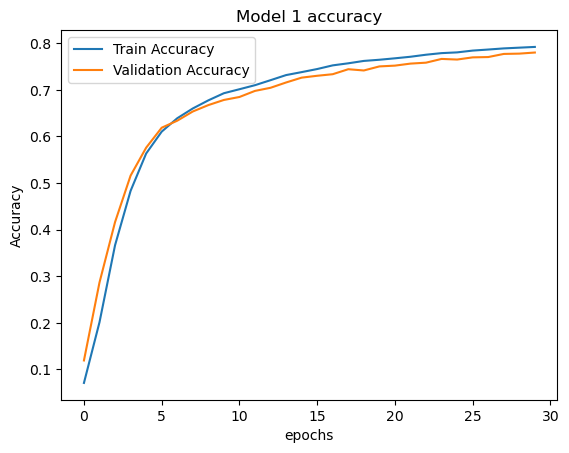

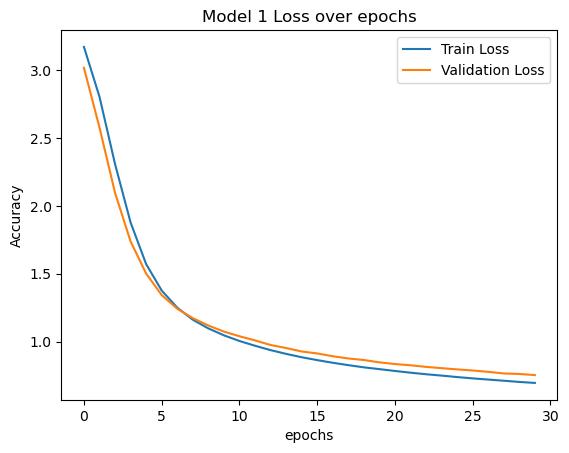

In [103]:
plt.plot(history1.history['accuracy'],label='Train Accuracy')
plt.plot(history1.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1 accuracy')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history1.history['loss'],label='Train Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.title('Model 1 Loss over epochs')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

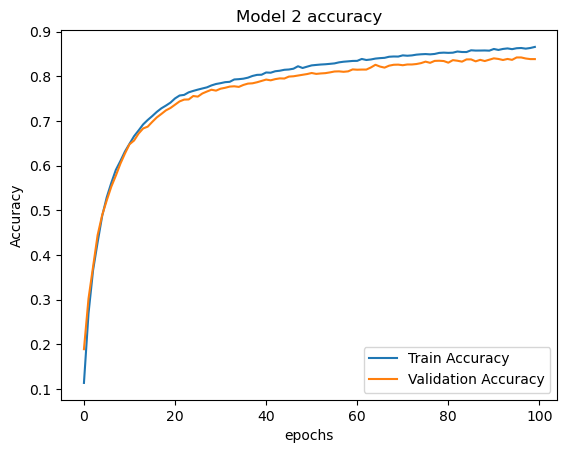

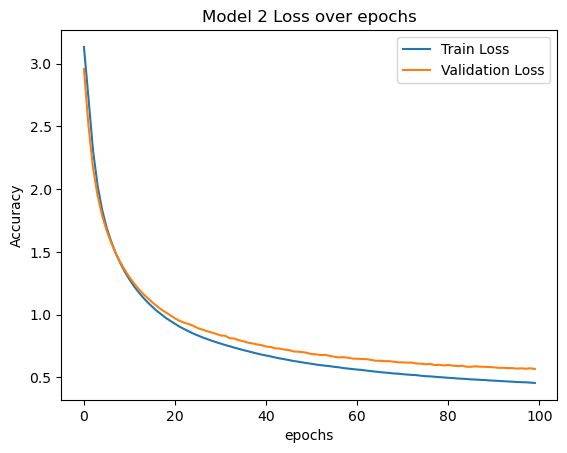

In [105]:
plt.plot(history.history['accuracy'],label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 2 accuracy')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'],label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model 2 Loss over epochs')
plt.xlabel('epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [107]:
# As we can see there is a slight improvement in the model performance.

In [109]:
# Hyperparameter Tuning

In [113]:
#pip install keras-tuner



   ---------------------------------------- 2/2 [keras-tuner]



In [115]:
import keras_tuner as kt

# Set dimensions
num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

# Define model-building function
def build_model(hp):
    model = keras.Sequential([
        keras.layers.Dense(
            units=hp.Int('units', min_value=16, max_value=128, step=16),
            activation=hp.Choice('activation', values=['relu', 'tanh', 'sigmoid']),
            input_shape=(num_features,)
        ),
        keras.layers.Dropout(hp.Float('dropout', min_value=0.1, max_value=0.5, step=0.1)),
        keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=hp.Choice('learning_rate', values=[0.1, 0.01, 0.001, 0.0001])
        ),
        loss='sparse_categorical_crossentropy',  # Use sparse format for integer labels
        metrics=['accuracy']
    )
    return model

In [119]:
from tensorflow import keras

In [121]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='alphabet_ann'
)

# Run the tuner
tuner.search(X_train, y_train, epochs=10, validation_split=0.2)

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Evaluate on test data
test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print("Best Tuned Test Accuracy:", test_accuracy)

Trial 5 Complete [00h 00m 05s]
val_accuracy: 0.7010378241539001

Best val_accuracy So Far: 0.8573819994926453
Total elapsed time: 00h 00m 26s
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 799us/step - accuracy: 0.8514 - loss: 0.4782
Best Tuned Test Accuracy: 0.8513658046722412


In [123]:
tuner.search(X_train,y_train,epochs=50,validation_split=0.2)

In [125]:
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"best hyperparameters={best_hyperparameters.values}")

best hyperparameters={'units': 80, 'activation': 'relu', 'dropout': 0.5, 'learning_rate': 0.01}


In [127]:
best_model = tuner.hypermodel.build(best_hyperparameters)
best_model.fit(X_train,y_train,epochs=100,validation_split=0.2)

Epoch 1/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5564 - loss: 1.4381 - val_accuracy: 0.7482 - val_loss: 0.8385
Epoch 2/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6692 - loss: 1.0346 - val_accuracy: 0.7800 - val_loss: 0.7009
Epoch 3/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6983 - loss: 0.9418 - val_accuracy: 0.8072 - val_loss: 0.6220
Epoch 4/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7150 - loss: 0.8892 - val_accuracy: 0.8169 - val_loss: 0.6071
Epoch 5/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7220 - loss: 0.8620 - val_accuracy: 0.8242 - val_loss: 0.5740
Epoch 6/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7293 - loss: 0.8309 - val_accuracy: 0.8339 - val_loss: 0.5332
Epoch 7/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7407 - loss: 0.8007 - val_accuracy: 0.8356 - val_loss: 0.5259
Epoch 8/100
374/374 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7407 - loss: 0.8049 - val_accu

In [131]:
train_loss, train_accuracy = best_model.evaluate(X_train, y_train)
print(f"Train Accuracy: {train_accuracy:.2f}")

test_loss, test_accuracy = best_model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")


467/467 ━━━━━━━━━━━━━━━━━━━━ 0s 693us/step - accuracy: 0.8956 - loss: 0.3395
Train Accuracy: 0.90
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 764us/step - accuracy: 0.8798 - loss: 0.4018
Test Accuracy: 0.88


In [133]:
# After performing keras tuner to find best parameters we got an accuracy of 91% which is really very good.

In [135]:
# Evaluation
from sklearn.metrics import accuracy_score

y_pred=best_model.predict(X_test).argmax(axis=1)
test_accuracy=accuracy_score(y_test,y_pred)
print("Test accuracy",test_accuracy)

117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 676us/step
Test accuracy 0.8797536154258169


In [137]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred, average='macro')  # Use 'macro' or 'weighted'
print(f"Precision: {precision:.2f}")

Precision: 0.88


In [139]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred, average='macro')
print(f"Recall: {recall:.3f}")

Recall: 0.881


In [141]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Score: {f1:.4f}")

F1-Score: 0.8805


In [ ]:
# ●	Discuss the performance differences between the model with default hyperparameters and the tuned model, emphasizing the effects of hyperparameter tuning.
Hyperparameter tuning significantly enhances model performance by adapting it to the specific dataset characteristics. While default parameters provide a fast starting point, tuning often yields models that are more accurate, stable, and generalizable.
While using a model with default hyperparameters the model may overfit or undefit due to no optimized parameters whereas Tuned model has reduced overfitting/underfitting through regularization parameters.
